In [94]:
import warnings
from warnings import filterwarnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import itertools
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import sklearn.tree as tree
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


In [95]:
wildfire = pd.read_csv("Weather_area.csv")
wildfire.head().style.set_properties(**{'background-color': 'black',
                           'color': 'lawngreen',
                           'border-color': 'white'})

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,Month,Year,Number_of_Fires,Area(hector)
0,canada,1/1/1990,2.300000,-12.000000,-5.700000,-1.400000,-18.800000,-13.400000,-8.600000,80.000000,2.000000,100.000000,4.170000,rain,0.000000,27.000000,nan,44.200000,273.500000,1004.500000,80.800000,16.700000,nan,nan,nan,nan,1990-01-01T07:42:46,1990-01-01T16:30:10,0.160000,"Rain, Partially cloudy",Partly cloudy throughout the day with early morning rain.,rain,"7,162,809,999,971,620,000,000",January,1990,0,0.000000
1,canada,1/2/1990,-0.900000,-13.400000,-4.800000,-6.400000,-17.100000,-10.600000,-8.000000,78.500000,0.200000,100.000000,4.170000,snow,2.109353,27.000000,nan,31.800000,222.100000,1017.900000,83.100000,22.600000,nan,nan,nan,nan,1990-01-02T07:42:47,1990-01-02T16:31:06,0.200000,"Snow, Partially cloudy",Partly cloudy throughout the day with early morning snow.,snow,"7,162,809,999,971,620,000,000",January,1990,0,0.000000
2,canada,1/3/1990,2.700000,-3.200000,-0.700000,-1.000000,-7.100000,-4.400000,-3.400000,82.300000,0.000000,0.000000,0.000000,"rain,snow",2.109353,20.500000,nan,16.400000,183.900000,1020.000000,88.700000,15.500000,nan,nan,nan,nan,1990-01-03T07:42:45,1990-01-03T16:32:04,0.230000,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"7,162,809,999,971,620,000,000",January,1990,0,0.000000
3,canada,1/4/1990,4.100000,1.400000,3.000000,2.100000,-3.900000,-0.500000,1.000000,87.500000,8.400000,100.000000,4.170000,rain,0.000000,13.000000,nan,28.100000,226.800000,1006.100000,99.700000,14.700000,nan,nan,nan,nan,1990-01-04T07:42:41,1990-01-04T16:33:03,0.250000,"Rain, Overcast",Cloudy skies throughout the day with late afternoon rain.,rain,"7,162,809,999,971,620,000,000",January,1990,0,0.000000
4,canada,1/5/1990,0.700000,-8.300000,-5.200000,-4.300000,-11.800000,-8.800000,-9.000000,75.100000,0.000000,0.000000,0.000000,"rain,snow",2.109353,11.000000,nan,22.400000,276.500000,1018.600000,63.800000,28.000000,nan,nan,nan,nan,1990-01-05T07:42:34,1990-01-05T16:34:05,0.300000,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"7,162,809,999,971,620,000,000",January,1990,0,0.000000


In [96]:
wildfire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12472 entries, 0 to 12471
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              12472 non-null  object 
 1   datetime          12472 non-null  object 
 2   tempmax           12472 non-null  float64
 3   tempmin           12472 non-null  float64
 4   temp              12472 non-null  float64
 5   feelslikemax      12472 non-null  float64
 6   feelslikemin      12472 non-null  float64
 7   feelslike         12472 non-null  float64
 8   dew               12472 non-null  float64
 9   humidity          12472 non-null  float64
 10  precip            12472 non-null  float64
 11  precipprob        12472 non-null  float64
 12  precipcover       12472 non-null  float64
 13  preciptype        9129 non-null   object 
 14  snow              12472 non-null  float64
 15  snowdepth         5432 non-null   float64
 16  windgust          4906 non-null   float6

In [97]:
# Assuming your original DataFrame is named 'wildfire'
# Selecting only the desired columns
new_df = wildfire[['tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'snow', 'windspeed','conditions','description', 'Month', 'Year', 'Number_of_Fires','Area(hector)']]

# Display the first few rows of the new DataFrame
new_df.head()


,tempmax,tempmin,temp,humidity,precip,snow,windspeed,conditions,description,Month,Year,Number_of_Fires,Area(hector)
0,2.3,-12.0,-5.7,80.0,2.0,0.000000,44.2,"Rain, Partially cloudy",Partly cloudy throughout the day with early mo...,January,1990,0,0.0
1,-0.9,-13.4,-4.8,78.5,0.2,2.109353,31.8,"Snow, Partially cloudy",Partly cloudy throughout the day with early mo...,January,1990,0,0.0
2,2.7,-3.2,-0.7,82.3,0.0,2.109353,16.4,Partially cloudy,Partly cloudy throughout the day.,January,1990,0,0.0
3,4.1,1.4,3.0,87.5,8.4,0.000000,28.1,"Rain, Overcast",Cloudy skies throughout the day with late afte...,January,1990,0,0.0
4,0.7,-8.3,-5.2,75.1,0.0,2.109353,22.4,Partially cloudy,Partly cloudy throughout the day.,January,1990,0,0.0


In [98]:
new_df.describe()

,tempmax,tempmin,temp,humidity,precip,snow,windspeed,Year,Number_of_Fires,Area(hector)
count,12472.000000,12472.000000,12472.000000,12472.000000,12472.000000,12472.000000,12472.000000,12472.000000,12472.000000,1.247200e+04
mean,11.435391,2.052718,6.841605,72.037652,2.493403,1.392397,20.993265,2006.575449,142.501764,1.283847e+04
std,12.385149,11.535399,11.749020,13.115686,6.371205,1.159783,7.605431,9.856654,252.658202,7.803152e+04
min,-24.900000,-32.300000,-27.800000,27.100000,0.000000,0.000000,2.600000,1990.000000,0.000000,0.000000e+00
25%,1.400000,-5.900000,-1.800000,63.700000,0.000000,0.000000,15.600000,1998.000000,2.000000,6.000000e-01
50%,12.100000,2.900000,7.700000,72.800000,0.039000,2.109353,20.100000,2007.000000,40.000000,1.298000e+02
75%,22.400000,11.900000,17.300000,81.600000,1.857000,2.109353,25.500000,2015.000000,162.000000,1.206500e+03
max,36.400000,24.400000,29.800000,100.000000,221.424000,25.100000,76.000000,2024.000000,2118.000000,1.143805e+06


C:\Users\siddh\AppData\Local\Temp\ipykernel_13864\2494044784.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


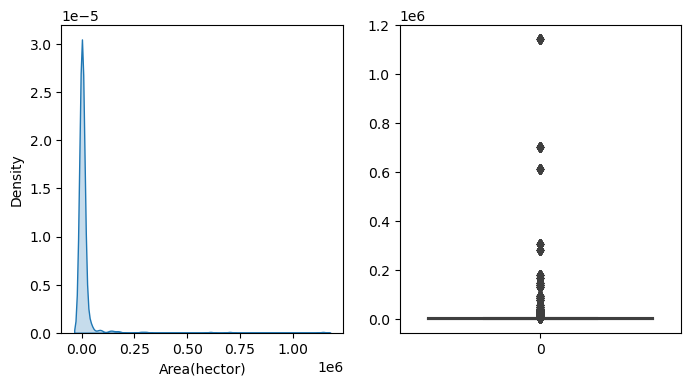

In [99]:
fig, ax =plt.subplots(1,2,figsize=(8,4))
sns.kdeplot(new_df['Area(hector)'],fill=True,ax=ax[0])
sns.boxplot(new_df['Area(hector)'],ax=ax[1])
fig.show()

The target is heavily skewed toward small values, with all larger ones being essentially outliers. As described in the documentation and paper, because the data are right-skewed, it is probably better to work with the transformation  x→ln(1+x)

Skewness: 10.70732165027357
Skewness after log transform: 0.19252875871685582


C:\Users\siddh\AppData\Local\Temp\ipykernel_13864\1510529471.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


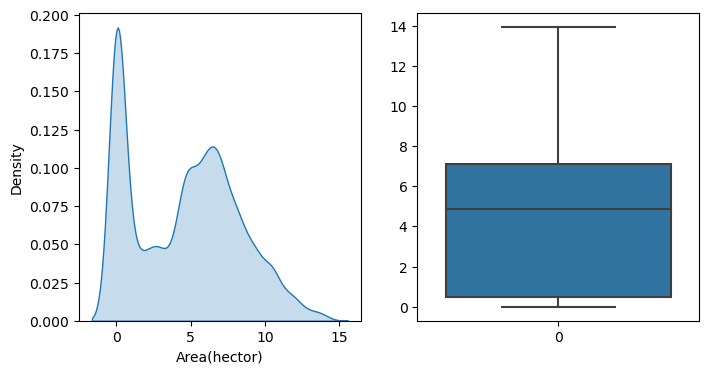

In [100]:
fig, ax =plt.subplots(1,2,figsize=(8,4))
sns.kdeplot(np.log(1+new_df['Area(hector)']),fill=True,ax=ax[0])
sns.boxplot(np.log(1+new_df['Area(hector)']),ax=ax[1])
fig.show()
area_log = np.log(1 + new_df['Area(hector)'])
print('Skewness:',new_df['Area(hector)'].skew())
print('Skewness after log transform:',area_log.skew())

In [101]:
new_df.sort_values(['Area(hector)'], ascending=[False]).head(10)

,tempmax,tempmin,temp,humidity,precip,snow,windspeed,conditions,description,Month,Year,Number_of_Fires,Area(hector)
10044,22.2,15.9,19.0,82.8,23.989,0.000000,15.1,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,July,2017,622,1143805.212
10059,25.6,18.1,21.6,79.3,0.996,0.000000,13.3,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,July,2017,622,1143805.212
10043,24.3,18.5,20.3,91.2,33.775,0.000000,21.5,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,July,2017,622,1143805.212
10072,28.2,11.9,20.1,65.1,0.018,0.000000,17.4,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,July,2017,622,1143805.212
10071,24.2,12.9,19.0,53.2,0.000,2.109353,17.3,Partially cloudy,Partly cloudy throughout the day.,July,2017,622,1143805.212
10070,23.0,14.0,18.5,61.2,0.000,2.109353,17.3,Partially cloudy,Partly cloudy throughout the day.,July,2017,622,1143805.212
10069,25.1,17.3,20.4,76.3,0.386,0.000000,24.4,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,July,2017,622,1143805.212
10068,21.7,11.9,17.7,81.4,0.029,0.000000,16.1,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,July,2017,622,1143805.212
10067,22.4,13.5,17.4,75.9,4.067,0.000000,22.1,"Rain, Partially cloudy",Partly cloudy throughout the day with rain cle...,July,2017,622,1143805.212
10066,18.3,13.8,15.1,85.5,50.707,0.000000,26.1,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,July,2017,622,1143805.212


In [102]:
new_df[new_df['Area(hector)'] == 0.]

,tempmax,tempmin,temp,humidity,precip,snow,windspeed,conditions,description,Month,Year,Number_of_Fires,Area(hector)
0,2.3,-12.0,-5.7,80.0,2.0,0.000000,44.2,"Rain, Partially cloudy",Partly cloudy throughout the day with early mo...,January,1990,0,0.0
1,-0.9,-13.4,-4.8,78.5,0.2,2.109353,31.8,"Snow, Partially cloudy",Partly cloudy throughout the day with early mo...,January,1990,0,0.0
2,2.7,-3.2,-0.7,82.3,0.0,2.109353,16.4,Partially cloudy,Partly cloudy throughout the day.,January,1990,0,0.0
3,4.1,1.4,3.0,87.5,8.4,0.000000,28.1,"Rain, Overcast",Cloudy skies throughout the day with late afte...,January,1990,0,0.0
4,0.7,-8.3,-5.2,75.1,0.0,2.109353,22.4,Partially cloudy,Partly cloudy throughout the day.,January,1990,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12467,-0.1,-10.3,-5.4,88.3,0.3,0.200000,10.8,Partially cloudy,Partly cloudy throughout the day.,Unspecified,2024,0,0.0
12468,-3.5,-14.0,-7.1,77.7,0.4,2.700000,22.7,Partially cloudy,Partly cloudy throughout the day.,Unspecified,2024,0,0.0
12469,-9.5,-15.3,-13.0,65.7,0.0,0.000000,19.1,Partially cloudy,Partly cloudy throughout the day.,Unspecified,2024,0,0.0
12470,-6.7,-15.3,-11.6,69.5,5.9,8.200000,10.8,Partially cloudy,Clearing in the afternoon.,Unspecified,2024,0,0.0


In [103]:
new_df[new_df['Area(hector)'] == 0.].describe()

,tempmax,tempmin,temp,humidity,precip,snow,windspeed,Year,Number_of_Fires,Area(hector)
count,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1975.0
mean,5.711190,-2.885367,1.499139,73.636203,2.272715,1.367979,21.490582,2014.876962,0.089620,0.0
std,12.435115,11.899712,11.954001,12.457911,5.495742,1.790310,7.511726,10.914495,0.445134,0.0
min,-24.500000,-31.400000,-26.400000,31.300000,0.000000,0.000000,2.600000,1990.000000,0.000000,0.0
25%,-3.000000,-11.850000,-7.150000,66.200000,0.000000,0.000000,16.300000,2011.000000,0.000000,0.0
50%,2.900000,-3.800000,-0.200000,74.700000,0.100000,2.109353,20.900000,2021.000000,0.000000,0.0
75%,16.100000,6.050000,11.200000,82.900000,1.619500,2.109353,25.900000,2022.000000,0.000000,0.0
max,33.100000,22.700000,26.900000,100.000000,70.617000,25.100000,53.000000,2024.000000,3.000000,0.0


In [104]:
# Store the original display options
original_float_format = pd.options.display.float_format

# Set display options to show numbers without exponential notation
pd.options.display.float_format = lambda x: '%.3f' % x

# Display the description of the DataFrame
print(new_df[new_df['Area(hector)'] != 0.].describe())

# Revert back to the original display options
pd.options.display.float_format = original_float_format


        tempmax   tempmin      temp  humidity    precip      snow  windspeed  \
count 10497.000 10497.000 10497.000 10497.000 10497.000 10497.000  10497.000   
mean     12.512     2.982     7.847    71.737     2.535     1.397     20.900   
std      12.077    11.226    11.435    13.215     6.522     0.998      7.620   
min     -24.900   -32.300   -27.800    27.100     0.000     0.000      3.200   
25%       2.900    -4.000    -0.400    63.300     0.000     0.000     15.400   
50%      14.000     4.100     9.100    72.500     0.030     2.109     19.800   
75%      23.100    12.300    17.800    81.400     1.905     2.109     25.300   
max      36.400    24.400    29.800   100.000   221.424     2.109     76.000   

           Year  Number_of_Fires  Area(hector)  
count 10497.000        10497.000     10497.000  
mean   2005.014          169.296     15254.018  
std       8.810          267.046     84839.858  
min    1990.000            0.000         0.001  
25%    1997.000            7.000  

In [105]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12472 entries, 0 to 12471
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tempmax          12472 non-null  float64
 1   tempmin          12472 non-null  float64
 2   temp             12472 non-null  float64
 3   humidity         12472 non-null  float64
 4   precip           12472 non-null  float64
 5   snow             12472 non-null  float64
 6   windspeed        12472 non-null  float64
 7   conditions       12472 non-null  object 
 8   description      12472 non-null  object 
 9   Month            12472 non-null  object 
 10  Year             12472 non-null  int64  
 11  Number_of_Fires  12472 non-null  int64  
 12  Area(hector)     12472 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 1.2+ MB


# Features

In [106]:
dfa = new_df.drop(columns='Area(hector)')
cat_columns = new_df.select_dtypes(include='object').columns.tolist()
num_columns = new_df.select_dtypes(exclude='object').columns.tolist()
print('Categorical features:',cat_columns)
print('Numerical features:',num_columns)

Categorical features: ['conditions', 'description', 'Month']
Numerical features: ['tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'snow', 'windspeed', 'Year', 'Number_of_Fires', 'Area(hector)']


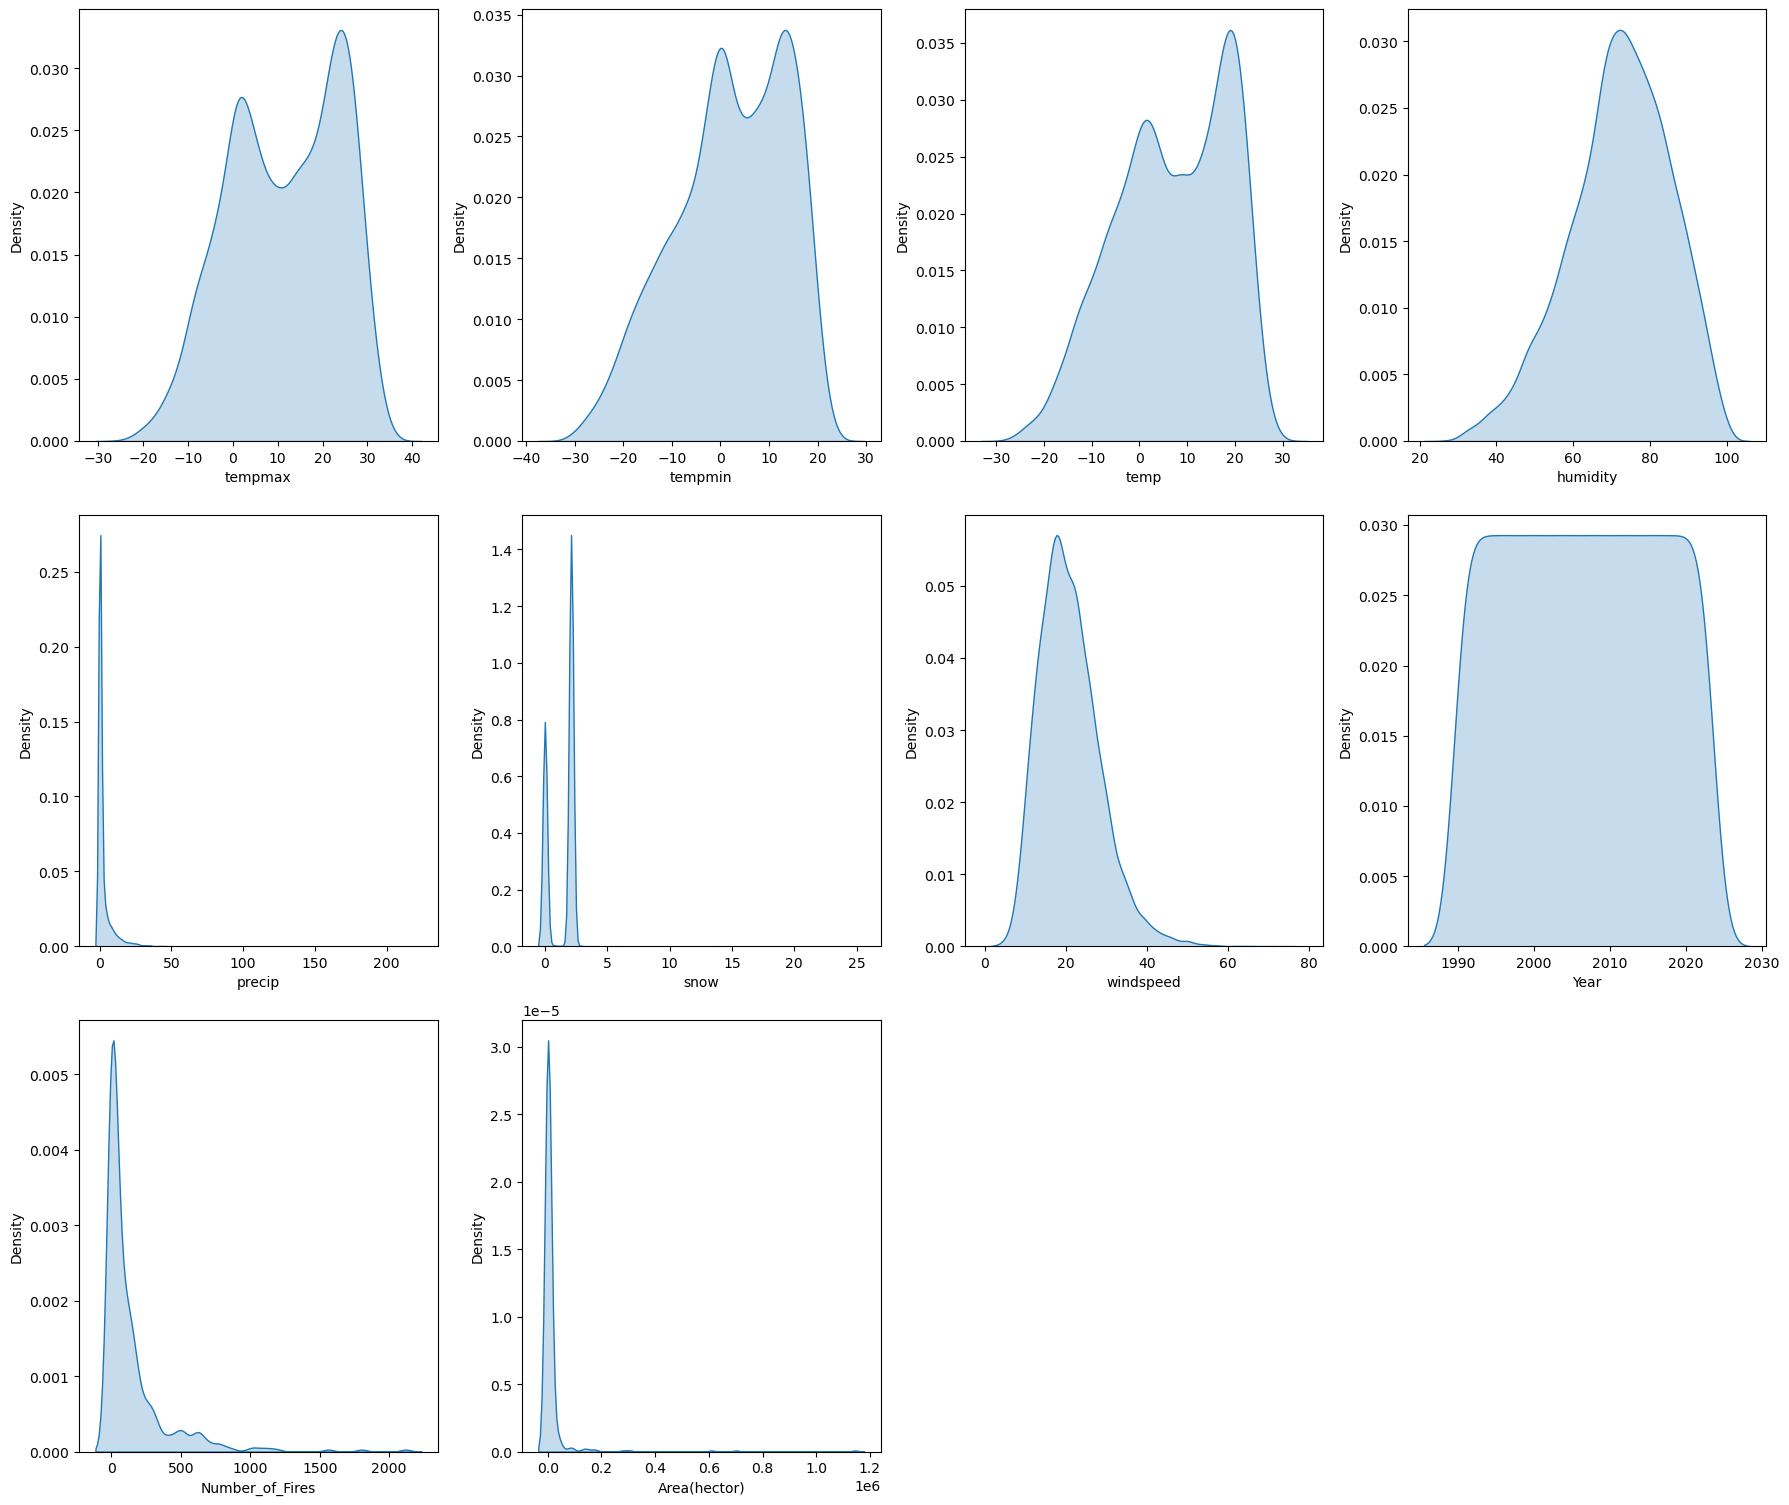

In [107]:
plt.figure(figsize=(18,40))
for i,col in enumerate(num_columns,1):
    plt.subplot(8,4,i)
    sns.kdeplot(new_df[col],fill=True)
plt.tight_layout() 
plt.show()

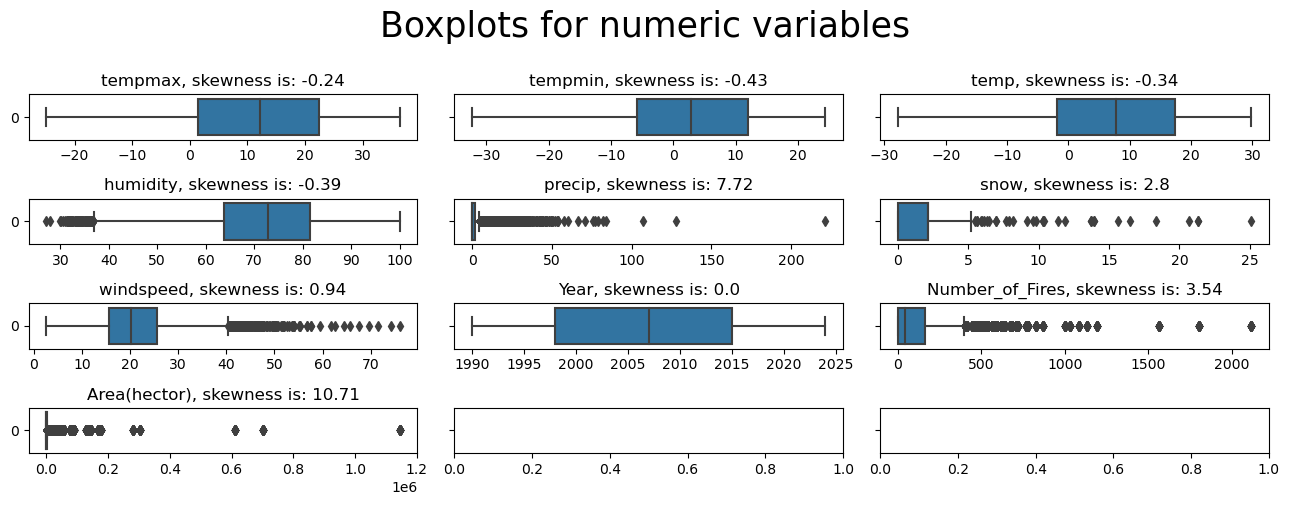

In [108]:
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(13,5))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
numerical_columns = list(new_df.loc[:,['tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'snow', 'windspeed', 'Year', 'Number_of_Fires', 'Area(hector)' ]])
                        
boxplots_custom(dataset=new_df, columns_list=numerical_columns, rows=4, cols=3, suptitle='Boxplots for numeric variables')
plt.tight_layout()

### For Categorical Columns

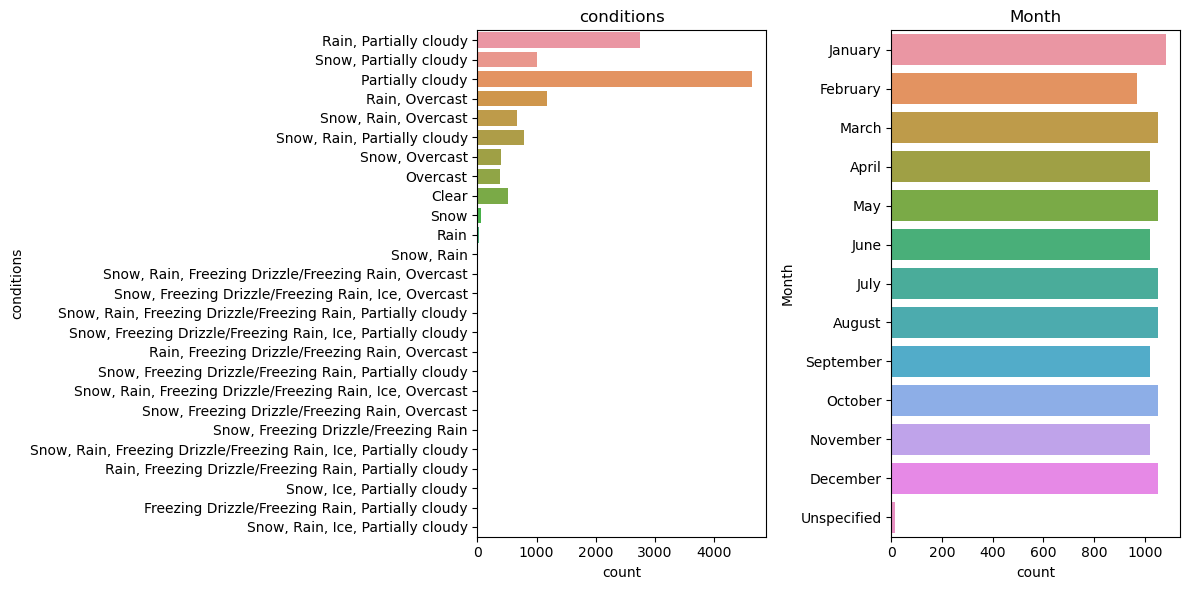

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only the desired columns
selected_columns = ["conditions", "Month"]
selected_df = new_df[selected_columns]

# Plot the bar graph
plt.figure(figsize=(12, 6))
for i, col in enumerate(selected_columns, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=selected_df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()


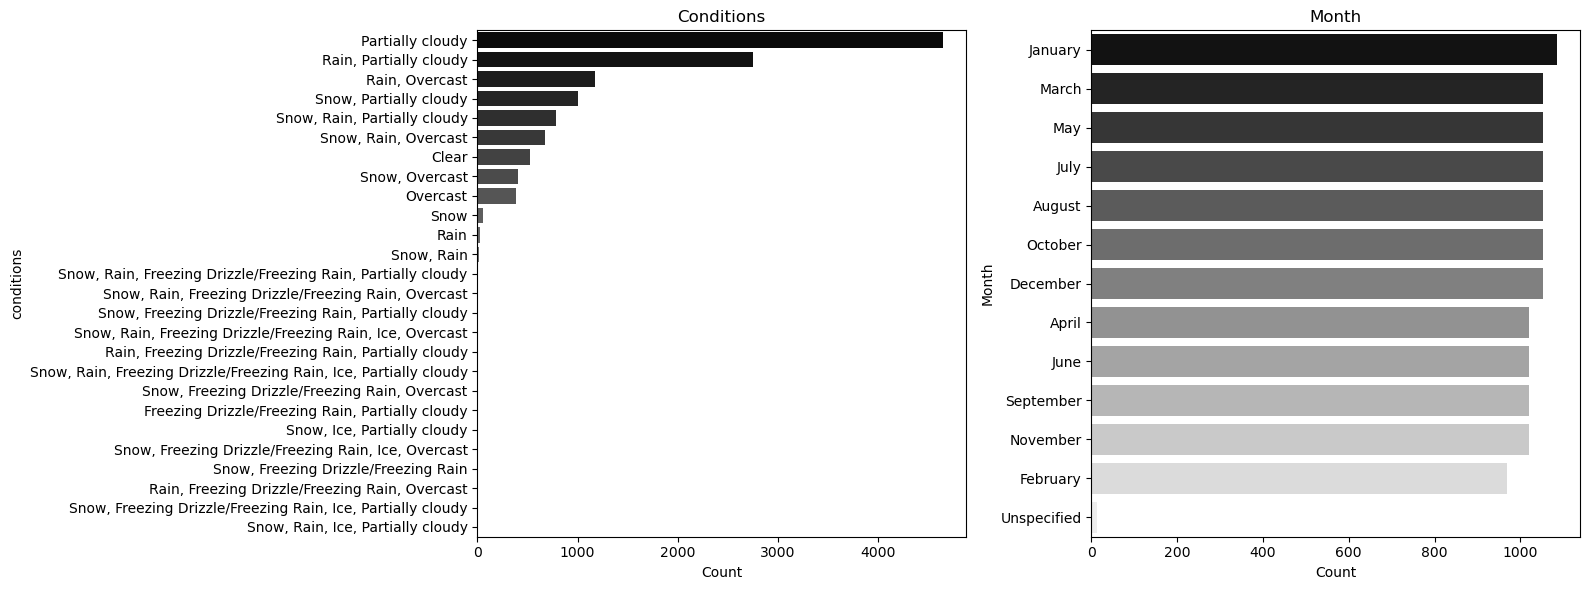

In [110]:
# Filter the DataFrame to include only the desired columns
selected_columns = ["conditions", "Month"]
selected_df = new_df[selected_columns]

# Count the occurrences of each category in the "conditions" column
conditions_counts = selected_df['conditions'].value_counts()

# Sort the counts in descending order
conditions_counts_sorted = conditions_counts.sort_values(ascending=False)

# Count the occurrences of each month
month_counts = selected_df['Month'].value_counts()

# Plot the bar graph
plt.figure(figsize=(16, 6))

# Plot the count of conditions
plt.subplot(1, 2, 1)
sns.countplot(data=selected_df, y='conditions', order=conditions_counts_sorted.index, palette='gray')
plt.title('Conditions')
plt.xlabel('Count')

# Plot the count of months
plt.subplot(1, 2, 2)
sns.countplot(data=selected_df, y='Month', palette='gray', order=month_counts.index)
plt.title('Month')
plt.xlabel('Count')

plt.tight_layout()
plt.show()


In [111]:
print('Number of rows with no damage:',new_df[new_df['Area(hector)'] == 0.].shape[0])
print('Number of rows with damage:',new_df[new_df['Area(hector)'] != 0.].shape[0])

Number of rows with no damage: 1975
Number of rows with damage: 10497


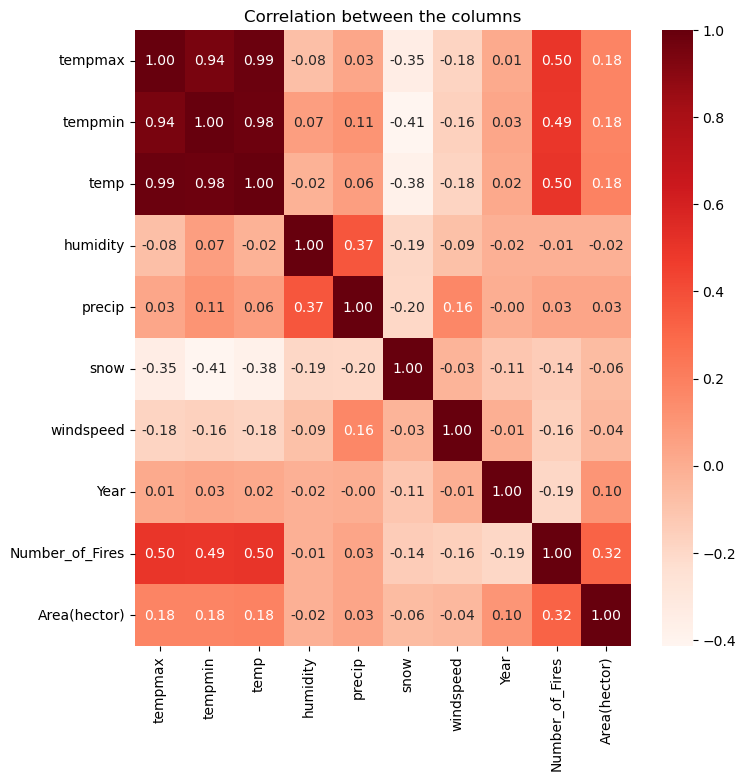

In [112]:
# Select only numeric columns from the DataFrame
numeric_columns = new_df.select_dtypes(include=['float64', 'int64'])

# Plot the correlation heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title("Correlation between the columns")
plt.show()


<Axes: >

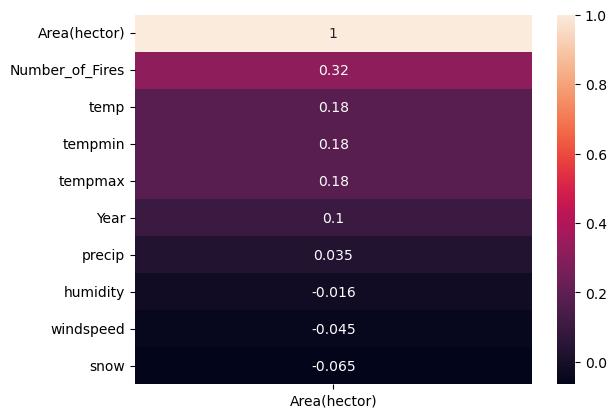

In [113]:
# Select only numeric columns from the DataFrame
numeric_columns = new_df.select_dtypes(include=['float64', 'int64'])
corr = numeric_columns.corr()[['Area(hector)']].sort_values(by='Area(hector)', ascending=False)
sns.heatmap(corr, annot=True)

# Model Building

In [115]:
categorical_features = [features for features in new_df.columns if new_df[features].dtypes =='O']
print(f"Now categorical variables are: {categorical_features}")
print(f"number of categorical variables are: {categorical_features}")

# see the head
# CANT COLOR A CATEGORICAL VARIABLE
new_df[categorical_features].head()

Now categorical variables are: ['conditions', 'description', 'Month']
number of categorical variables are: ['conditions', 'description', 'Month']


,conditions,description,Month
0,"Rain, Partially cloudy",Partly cloudy throughout the day with early mo...,January
1,"Snow, Partially cloudy",Partly cloudy throughout the day with early mo...,January
2,Partially cloudy,Partly cloudy throughout the day.,January
3,"Rain, Overcast",Cloudy skies throughout the day with late afte...,January
4,Partially cloudy,Partly cloudy throughout the day.,January


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for i in categorical_features:
    new_df[i]=label_encoder.fit_transform(new_df[i])

In [117]:
all_fe = ['conditions', 'description', 'Month','tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'snow', 'windspeed', 'Year', 'Number_of_Fires', 'Area(hector)']

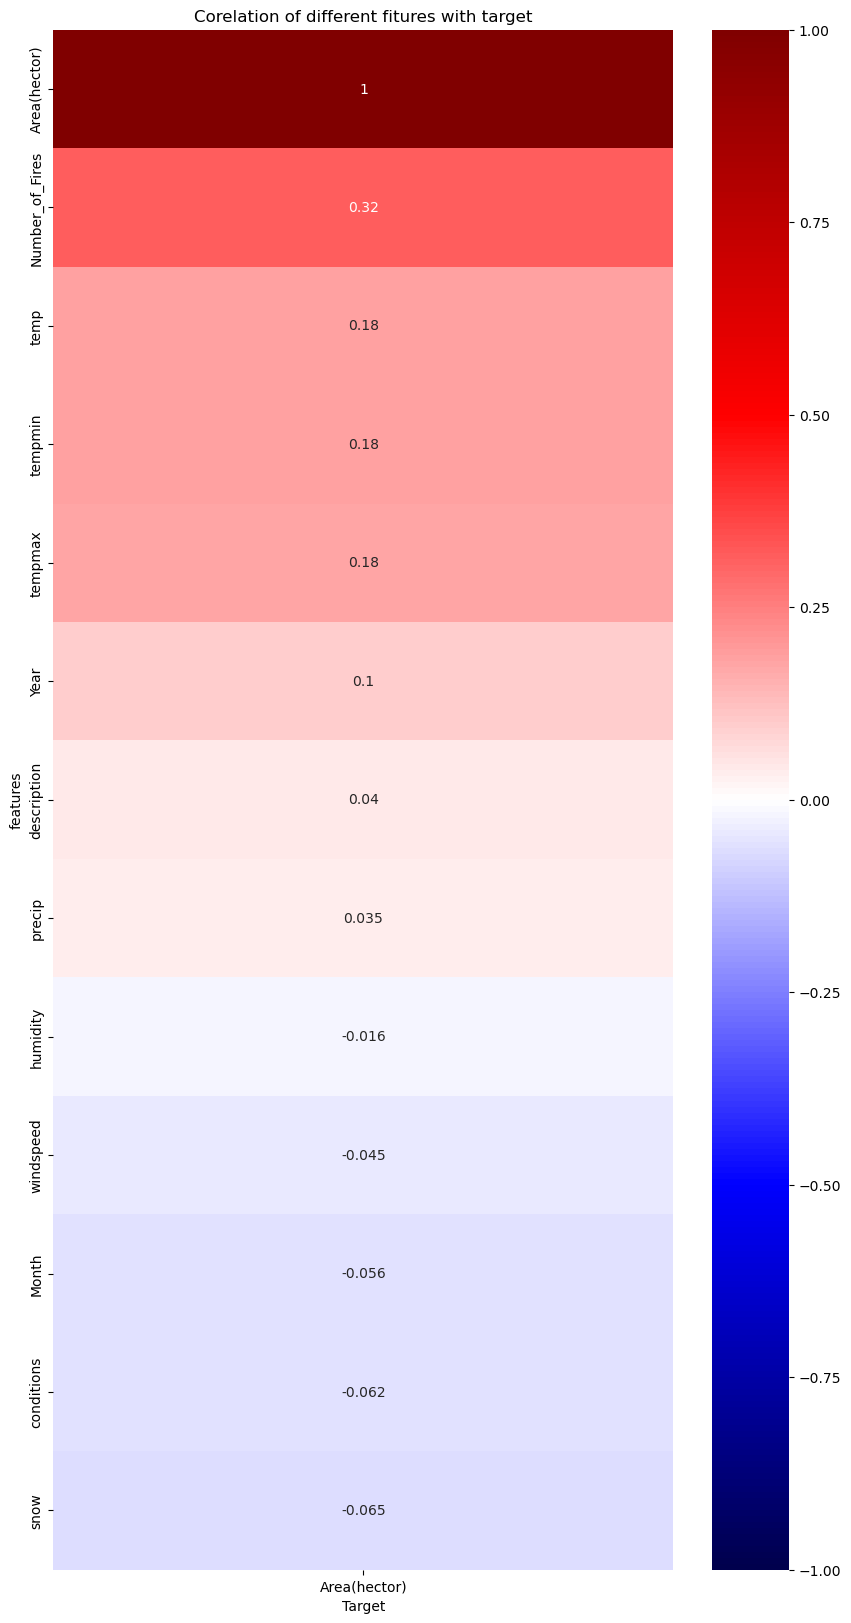

In [118]:
corr_new_train=new_df.corr()
plt.figure(figsize=(10,20))
sns.heatmap(corr_new_train[['Area(hector)']].sort_values(by=['Area(hector)'],ascending=False).head(60),vmin=-1, cmap='seismic', annot=True)
plt.ylabel('features')
plt.xlabel('Target')
plt.title("Corelation of different fitures with target")
plt.show()

In [119]:
fs1 = ['Number_of_Fires','Area(hector)','tempmin','tempmax','temp','precip','humidity','Month','windspeed'] 

In [151]:
df_fs1 = new_df[fs1]
df_fs1.head()

,Number_of_Fires,Area(hector),tempmin,tempmax,temp,precip,humidity,Month,windspeed
0,0,0.0,-12.0,2.3,-5.7,2.0,80.0,4,44.2
1,0,0.0,-13.4,-0.9,-4.8,0.2,78.5,4,31.8
2,0,0.0,-3.2,2.7,-0.7,0.0,82.3,4,16.4
3,0,0.0,1.4,4.1,3.0,8.4,87.5,4,28.1
4,0,0.0,-8.3,0.7,-5.2,0.0,75.1,4,22.4


In [153]:
SEED = 42

data = df_fs1.copy()
y = data['Area(hector)']
x = data.drop(['Area(hector)'],axis=1)


from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2,random_state = SEED)

In [142]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

In [154]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['sqrt','log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
#Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]# 
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]



random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

In [155]:
reg_rf_rscv = RandomForestRegressor()

In [156]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
random_search_rf = RandomizedSearchCV(reg_rf_rscv, random_grid,n_iter=5, n_jobs=1, cv=5,verbose=2)

In [157]:
random_search_rf.fit(x_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END bootstrap=True, max_depth=70, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   2.9s
[CV] END bootstrap=True, max_depth=70, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   2.9s
[CV] END bootstrap=True, max_depth=70, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   3.0s
[CV] END bootstrap=True, max_depth=70, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   2.9s
[CV] END bootstrap=True, max_depth=70, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   3.3s
[CV] END bootstrap=False, max_depth=60, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=800; total time=  21.3s
[CV] END bootstrap=False, max_depth=60, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=800; 

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=5, n_jobs=1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   verbose=2)

In [158]:
random_search_rf.best_params_

{'n_estimators': 800,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 60,
 'bootstrap': False}

In [164]:
base_model = RandomForestRegressor(n_estimators= 1200,
                                     min_samples_split= 10,
                                     min_samples_leaf= 2,
                                     max_features= 'sqrt',
                                     max_depth= 20,
                                     bootstrap= True,
                                    random_state = SEED)
base_model.fit(x_train, y_train)
#base_accuracy = evaluate(base_model, x_val,y_val)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=10, n_estimators=1200, random_state=42)

In [165]:
y_pred_rf_rscv = base_model.predict(x_val)

In [166]:
def MSE(model_preds, ground_truths):
  return mean_squared_error(model_preds, ground_truths)

def MAE(model_preds, ground_truths):
  return mean_absolute_error(model_preds, ground_truths)

def Other_Err(model_preds, ground_truths):
  return r2_score( ground_truths,model_preds)

def RMSE(model_preds, ground_truths):
  return np.sqrt(mean_squared_error(model_preds, ground_truths))

In [167]:
print(f"mean squared error: {MSE(y_pred_rf_rscv,y_val)}")
print(f"mean absolute error: {MAE(y_pred_rf_rscv,y_val)}")
print(f"r2 error: {Other_Err(y_pred_rf_rscv,y_val)}")
print(f"root mean squared error: {RMSE(y_pred_rf_rscv,y_val)}")

mean squared error: 1416031575.8273838
mean absolute error: 9317.90030966718
r2 error: 0.6704110512806412
root mean squared error: 37630.19500118733


In [169]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

In [170]:
score = cross_val_score(reg_rf_rscv, x_train, y_train, cv=k_fold, n_jobs=1, scoring='r2')
print(score)

[0.97071063 0.95495262 0.9864531  0.95460991 0.9484511  0.95592125
 0.96802013 0.96717197 0.97521201 0.98367956]


In [171]:
print('train r2 %2f' %(1 * score.mean()))

train r2 0.966518


In [172]:
score_val = cross_val_score(reg_rf_rscv, x_val, y_val, cv=k_fold, n_jobs=1, scoring='r2')
print(score)

[0.97071063 0.95495262 0.9864531  0.95460991 0.9484511  0.95592125
 0.96802013 0.96717197 0.97521201 0.98367956]


In [173]:
print('train r2 %2f' %(1 * score_val.mean()))

train r2 0.554439


In [188]:
!pip install chart_studio

     ---------------------------------------- 0.0/64.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/64.4 kB ? eta -:--:--
     ------------------------------------ - 61.4/64.4 kB 812.7 kB/s eta 0:00:01
     -------------------------------------- 64.4/64.4 kB 694.6 kB/s eta 0:00:00
